<h1 style="text-align: center;"><strong>Machine Learning & Data Science</strong></h1>
<h2 style="text-align: center;"><strong>Analise Exploratória I - Conhecendo os dados</strong></h2>
<h3 style="text-align: center;"><strong>Eduardo Ferreira</strong></h3>
<h4 style="text-align: center;"><strong>eduds1010@gmail.com</strong></h4>
<h5 style="text-align: center;"><strong>https://github.com/blequizit</strong></h5>
<br>
<p style="text-align: center;"><em>Este projeto aplica técnicas de análise exploratória e regressão linear, incluindo modelos de regressão simples e múltipla, para entender a relação entre variáveis explicativas e o tempo de armageddon, com o objetivo de prever e avaliar a performance do modelo através de métricas como R² e p-values.</em></p>
<br>


## **Regressão Linear**

Alguns fatores são cruciais para saber se nosso modelo tem uma boa performance.



*   **Test F de Significancia Global.:** Afirma se ao menos uma variável do meu modelo está relacionada com a variável alvo. Para isso, o valor-p desta estatística precisa ser menor que 0.05

*   **Teste de Significancia individuais ou p-values dos coeficientes.:** Diz o quanto das variáveis preditoras explicam a variável alvo. A métrica padrão é o p-value ser menor que 0.05.


*   **Coeficiente R².:** Diz o quanto o meu modelo explica seus resultados. É um valor entre 0 e 1. Quanto mais próximo de 1, melhor.


#### **Sobre o R²**

O R², também chamado de Coeficiente de Determinação, diz o quanto meu modelo está prevendo corretamente. O cálculo dele, envolve três medidas:


*   **Soma Total dos Quadrados (STQ):** mostra a variação de y em torno da própria média. É o somatório das diferenças entre o valor alvo real e sua média elevado ao quadrado.

*   **Soma dos Quadrados dos Resíduos (SQU):** variação de Y que não é explicada pelo modelo elaborado. É o somatório das diferenças entre o valor predito e o valor real elevados ao quadrado.


*   **Soma dos Quadrados de Regressão (SQR):** oferece a variação de Y considerando as variáveis X utilizadas no modelo. É a diferença entre o valor de SQT e SQU. Portanto: SQR = SQT — SQU.

O valor de R² é o próprio SQR dividido pelo SQT, ou seja, é divisão da variação explicada pelo variação total dos dados.













#Biliotecas

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot

#Leitura dos Dados

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning & Data Science/Dados/dataset_armageddon_final_corrected.csv")

In [ ]:
df.sample(5)

,peso,potencia,velocidade_max,tipo_cambio,tipo_pneu,tipo_motor,sobrealimentacao,carroceria,tracao,pista,titulos_armageddon,vitorias_lista_estado,tempo_armageddon_s
1811,1545.522475,2024.368005,275.090064,Sapinho,Hoosier,V6,Bi-Turbo,Fibra de Vidro,Traseira,Pista Tratada,8,46,5.651418
2161,1313.347139,2622.984934,291.499300,Sapinho,Hoosier,V8,Supercharger,Fibra de Carbono,Dianteira,No Prep,8,41,4.777286
2120,1499.675606,2345.642710,281.160376,Liberty,Mickey Thompson,V6,Bi-Turbo,Fibra de Carbono,4x4,No Prep,0,25,5.232110
223,1241.258964,1180.023381,266.515720,Sapinho,Hoosier,V6,Single Turbo,Metal,Traseira,Pista Tratada,1,31,6.403637
4,888.500132,1127.125531,274.105135,Sapinho,Mickey Thompson,AP,Aspirado,Fibra de Vidro,Dianteira,Pista Tratada,1,37,5.793402


# **Regressão Linear Simples**

In [ ]:
y = df["tempo_armageddon_s"] # Variável dependente
X = df["potencia"] # Variável independente, explicativa

In [ ]:
model = sm.OLS(y, sm.add_constant(X)).fit() # Treina o modelo dwe regressão linear simples

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     tempo_armageddon_s   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                 1.244e+04
Date:                Fri, 14 Mar 2025   Prob (F-statistic):               0.00
Time:                        01:25:07   Log-Likelihood:                -977.90
No. Observations:                3000   AIC:                             1960.
Df Residuals:                    2998   BIC:                             1972.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6390      0.021    371.117      0.0

In [ ]:
sm.stats.anova_lm(ols("tempo_armageddon_s ~ potencia", data=df).fit())

,df,sum_sq,mean_sq,F,PR(>F)
potencia,1.0,1398.593987,1398.593987,12437.826483,0.0
Residual,2998.0,337.115555,0.112447,NaN,NaN


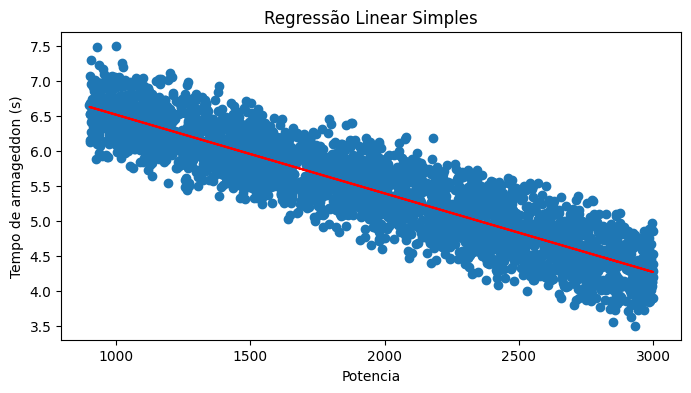

In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(X,y)
plt.plot(X, model.predict(), color="r")
plt.xlabel("Potencia")
plt.ylabel("Tempo de armageddon (s)")
plt.title("Regressão Linear Simples")
plt.show()

# **Testes com outros variáveis**

In [ ]:
y = df["tempo_armageddon_s"] # Variável dependente
X = df[["peso", "potencia"]] # Variável independente, explicativa

In [ ]:
model = sm.OLS(y, sm.add_constant(X)).fit() # Treina o modelo dwe regressão linear simples

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     tempo_armageddon_s   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 2.195e+04
Date:                Fri, 14 Mar 2025   Prob (F-statistic):               0.00
Time:                        01:47:14   Log-Likelihood:                 689.31
No. Observations:                3000   AIC:                            -1373.
Df Residuals:                    2997   BIC:                            -1355.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.5740      0.018    364.620      0.0

# **Transformando variáveis categoricas**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
df.sample(4)

,peso,potencia,velocidade_max,tipo_cambio,tipo_pneu,tipo_motor,sobrealimentacao,carroceria,tracao,pista,titulos_armageddon,vitorias_lista_estado,tempo_armageddon_s
600,902.449868,1610.285031,286.418422,2,2,0,2,1,2,1,2,17,5.637825
1720,873.629318,1358.373717,280.939852,0,2,1,1,1,1,1,2,44,5.773606
2408,1985.643159,2214.566219,270.445797,0,1,1,2,2,0,0,9,42,5.467029
457,1362.392770,1088.088651,262.886829,1,1,2,2,2,0,1,4,41,6.177462


# **Regressão Multipla com dataset inteiro**

In [ ]:
y = df["tempo_armageddon_s"] # Variável dependente
X = df.drop("tempo_armageddon_s", axis=1) # Usa todas as variáveis menos a dependente

In [ ]:
model = sm.OLS(y, sm.add_constant(X)).fit() # Treina o modelo de regressão linear simples

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     tempo_armageddon_s   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     5743.
Date:                Fri, 14 Mar 2025   Prob (F-statistic):               0.00
Time:                        01:52:53   Log-Likelihood:                 1335.5
No. Observations:                3000   AIC:                            -2645.
Df Residuals:                    2987   BIC:                            -2567.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     7.09